In [ ]:
pip install -r requirements.txt

In [1]:
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns

from data_utils import AttributesDataset, ClassificationDataset, albumentation_transforms, compute_class_weights
from network.domain_adaptation_net import Feature_extractor, Class_classifier, Domain_classifier
from solver import Solver
from vis_utils import visualize_grid

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.manifold import TSNE

# Setup CUDA device
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

Source Train size: 11528
Source Val size: 2379
Target Train size: 11544
Target Val size: 2183
------------------------------------------------------------------------
Center cell Img size:  torch.Size([3, 120, 120])
Full crop Img size:  torch.Size([3, 120, 120])
Concatenated Img size:  torch.Size([6, 120, 120])
------------------------------------------------------------------------
Size classes:  ['MACR' 'MICR' 'NORM']
Shape classes:  ['ACAN' 'BITE' 'ECHI' 'ELLI' 'HELM' 'NONE' 'OVAL' 'SCHI' 'SICK' 'SPHE'
 'TEAR']
Hemoglobin distribution classes:  ['HYPO' 'HYPR' 'NONE' 'STOM' 'TARG']
Inclusion classes:  ['BAST', 'HOJO', 'MALA', 'NONE', 'NRBC', 'PABO', 'RETI']
------------------------------------------------------------------------


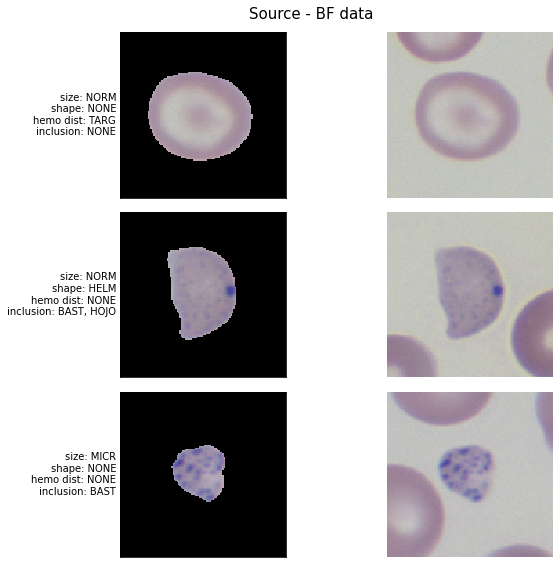

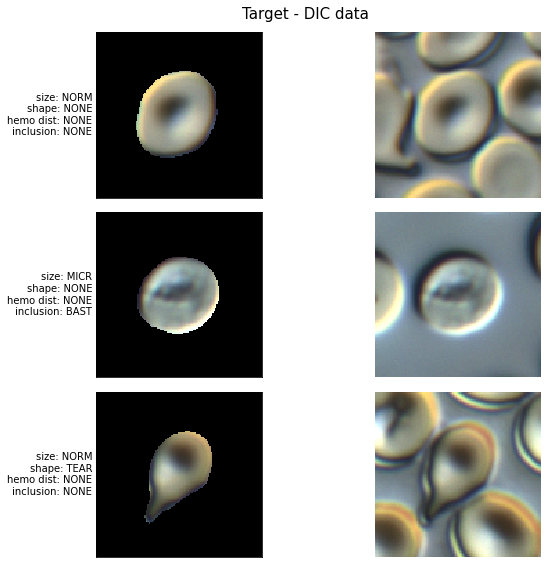

In [2]:
source_data_folder_center = 'data/bf/good_images_center'         # source = BF(stained) images
source_data_folder_full = 'data/bf/good_images'

target_data_folder_center = 'data/dic/good_images_center'       # target = DIC(Unstained) images
target_data_folder_full = 'data/dic/good_images'

attributes = AttributesDataset('data/all_data_new_clean1.csv')

# source and target trainset transforms for center and full crop
to_tensor_source_trainset_center = transforms.Compose([transforms.ToTensor(),
                                                      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])                                                        
to_tensor_source_trainset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.6872, 0.6295, 0.6625), (0.0891, 0.1300, 0.0741))])  
                             
to_tensor_target_trainset_center = transforms.Compose([transforms.ToTensor(),
                                                       transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
to_tensor_target_trainset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.4932, 0.5287, 0.5088), (0.1627, 0.1568, 0.1282))])
                             
# source and target valset transforms for center and full crop
to_tensor_source_valset_center = transforms.Compose([transforms.ToTensor(),
                                                     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
to_tensor_source_valset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.6869, 0.6237, 0.6573), (0.0812, 0.1271, 0.0747))]) 
                                                       
to_tensor_target_valset_center = transforms.Compose([transforms.ToTensor(),
                                                     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
to_tensor_target_valset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5023, 0.5367, 0.5102), (0.1692, 0.1617, 0.1303))])
                                       
      

source_train_data = ClassificationDataset(source_data_folder_center, source_data_folder_full,'data/bf/train_processed_new_clean1.csv',attributes,\
            to_tensor_center = to_tensor_source_trainset_center, to_tensor_full = to_tensor_source_trainset_full, aug_transforms = albumentation_transforms())

target_train_data = ClassificationDataset(target_data_folder_center, target_data_folder_full,'data/dic/train_processed_new_clean1.csv',attributes,\
            to_tensor_center = to_tensor_target_trainset_center, to_tensor_full = to_tensor_target_trainset_full, aug_transforms = albumentation_transforms())

source_val_data = ClassificationDataset(source_data_folder_center, source_data_folder_full,'data/bf/test_new_clean.csv', attributes, \
            to_tensor_center = to_tensor_source_valset_center, to_tensor_full = to_tensor_source_valset_full)

target_val_data = ClassificationDataset(target_data_folder_center, target_data_folder_full,'data/dic/test_new_clean.csv', attributes, \
            to_tensor_center = to_tensor_target_valset_center, to_tensor_full = to_tensor_target_valset_full)

print("Source Train size: %i" % len(source_train_data))
print("Source Val size: %i" % len(source_val_data))
print("Target Train size: %i" % len(target_train_data))
print("Target Val size: %i" % len(target_val_data))
print('------------------------------------------------------------------------')
print("Center cell Img size: ", source_train_data[0]['img_center_cell'].size())
print("Full crop Img size: ", source_train_data[0]['img_full_crop'].size())
print("Concatenated Img size: ", source_train_data[0]['img'].size())
print('------------------------------------------------------------------------')
print("Size classes: ",attributes.size_labels)
print("Shape classes: ",attributes.shape_labels)
print("Hemoglobin distribution classes: ",attributes.hemo_dist_labels)
print("Inclusion classes: ",attributes.inclusion_labels)
print('------------------------------------------------------------------------')
# visualization of source data.
num_example_imgs = 3
for i, dict_item in enumerate(source_train_data[0:num_example_imgs]):
    
    size_label = attributes.size_id_to_name[dict_item['labels']['size_label']]
    shape_label = attributes.shape_id_to_name[dict_item['labels']['shape_label']]
    hemo_dist_label = attributes.hemo_dist_id_to_name[dict_item['labels']['hemo_dist_label']]
    inclusion_label = np.array(attributes.inclusion_labels)[np.argwhere(dict_item['labels']['inclusion_label'] > 0)[:, 0]]
    label = "size: {}\nshape: {}\nhemo dist: {}\ninclusion: {}".format(size_label, shape_label, hemo_dist_label, ', '.join(inclusion_label))
 
    plt.subplot(num_example_imgs, 2, i * 2 + 1)
    img = dict_item['img_center_cell']                  #normalized between (0,1)
    img[0] = img[0]*0.5 + 0.5
    img[1] = img[1]*0.5 + 0.5
    img[2] = img[2]*0.5 + 0.5
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.xticks([])
    plt.yticks([])
    plt.ylabel(label, fontsize=10, rotation ='horizontal', ha ='right', va='center')
    
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    img = dict_item['img_full_crop']
    # unnormalize                              
    img[0] = img[0]*0.0891 + 0.6872
    img[1] = img[1]*0.1300 + 0.6295
    img[2] = img[2]*0.0741 + 0.6625
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.axis('off')
plt.suptitle("Source - BF data", fontsize =15)      
plt.tight_layout()    
plt.show()

# visualization of target data.
for i, dict_item in enumerate(target_train_data[0:num_example_imgs]):
    
    size_label = attributes.size_id_to_name[dict_item['labels']['size_label']]
    shape_label = attributes.shape_id_to_name[dict_item['labels']['shape_label']]
    hemo_dist_label = attributes.hemo_dist_id_to_name[dict_item['labels']['hemo_dist_label']]
    inclusion_label = np.array(attributes.inclusion_labels)[np.argwhere(dict_item['labels']['inclusion_label'] > 0)[:, 0]]
    label = "size: {}\nshape: {}\nhemo dist: {}\ninclusion: {}".format(size_label, shape_label, hemo_dist_label, ', '.join(inclusion_label))
    
    plt.subplot(num_example_imgs, 2, i * 2 + 1)
    img = dict_item['img_center_cell']                 #normalized between (0,1)
    img[0] = img[0]*0.5 + 0.5
    img[1] = img[1]*0.5 + 0.5
    img[2] = img[2]*0.5 + 0.5
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.xticks([])
    plt.yticks([])
    plt.ylabel(label, fontsize=10, rotation ='horizontal', ha ='right', va='center')
    
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    img = dict_item['img_full_crop']
    # unnormalize                              
    img[0] = img[0]*0.1627 + 0.4932
    img[1] = img[1]*0.1568 + 0.5287
    img[2] = img[2]*0.1282 + 0.5088
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.axis('off')
plt.suptitle("Target - DIC data", fontsize =15)    
plt.tight_layout()    
plt.show()

In [3]:
src_size, src_shape, src_hemo, src_inc_ones, src_inc_zeros = compute_class_weights(source_train_data, attributes)   
src_hemo                                

{'HYPO': 0.4176285414480588,
 'HYPR': 1.0,
 'NONE': 0.041277743206803566,
 'STOM': 1.9800995024875618,
 'TARG': 1.1916167664670658}

In [4]:
import random
def set_seed(seed): 
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False 
    torch.manual_seed(seed) 
    torch.cuda.manual_seed_all(seed) 
    np.random.seed(seed) 
    random.seed(seed)
    
set_seed(2021)

In [5]:
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

In [6]:
print('#### Test Case ###')
from torch.autograd import Variable

x = Variable(torch.rand(15,3,120,120)).to(device)
model = Feature_extractor().to(device)
model2= Class_classifier(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)
model3 = Domain_classifier().to(device)
#param = count_param(model)
y = model(x)
y1 = model2(y)
y2 = model3(y, 5.0)
print('Output shape:',y.shape)
print('Output shape:',y1['hemo_dist'].shape)
print('Output shape:',y2.shape)

#### Test Case ###
Loaded pretrained weights for efficientnet-b7
Output shape: torch.Size([15, 2560])
Output shape: torch.Size([15, 5])
Output shape: torch.Size([15, 2])


Loaded pretrained weights for efficientnet-b7
START TRAIN.
Epoch  0  Train src hemo loss  0.8278485508042277  Train domain loss  0.6182843703477336  Val tgt acc hemo 0.4056308654848801
Epoch  1  Train src hemo loss  0.43383700764348465  Train domain loss  0.4052054584232724  Val tgt acc hemo 0.684045881126173
Epoch  2  Train src hemo loss  0.35778593352977756  Train domain loss  0.8615768865947908  Val tgt acc hemo 0.7080943691345151
Epoch  3  Train src hemo loss  0.33168727488687827  Train domain loss  1.17354843169038  Val tgt acc hemo 0.5838764337851929
Epoch  4  Train src hemo loss  0.3056158524966306  Train domain loss  1.3830709898240678  Val tgt acc hemo 0.7457638164754954
Epoch  5  Train src hemo loss  0.32855966098482753  Train domain loss  1.5327409807995085  Val tgt acc hemo 0.6258472367049009
Epoch  6  Train src hemo loss  0.2742340412620362  Train domain loss  1.3571055244210684  Val tgt acc hemo 0.7383342022940562
Epoch  7  Train src hemo loss  0.21712246869879046  Train 

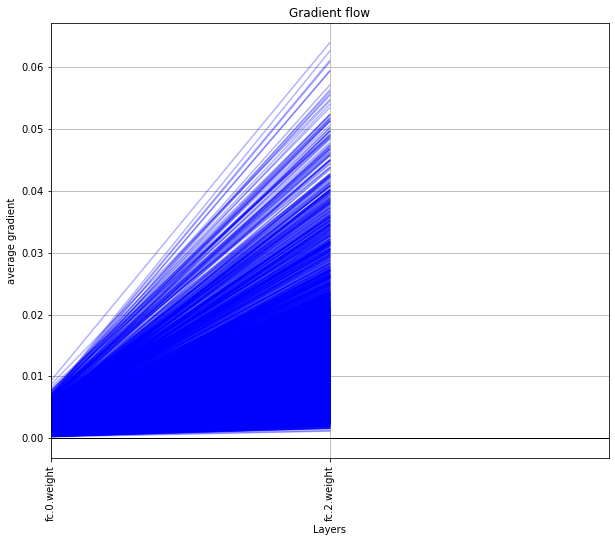

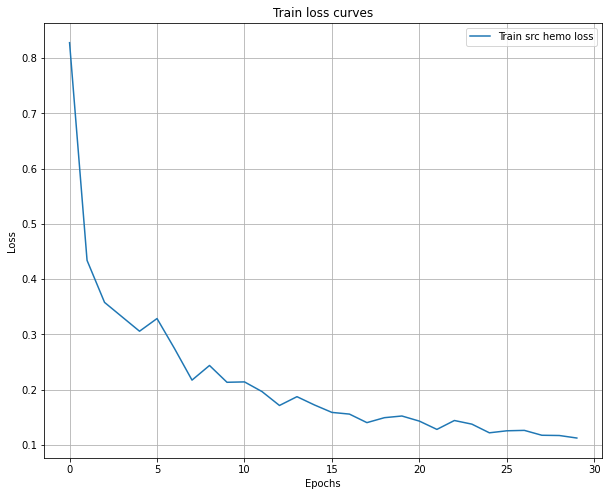

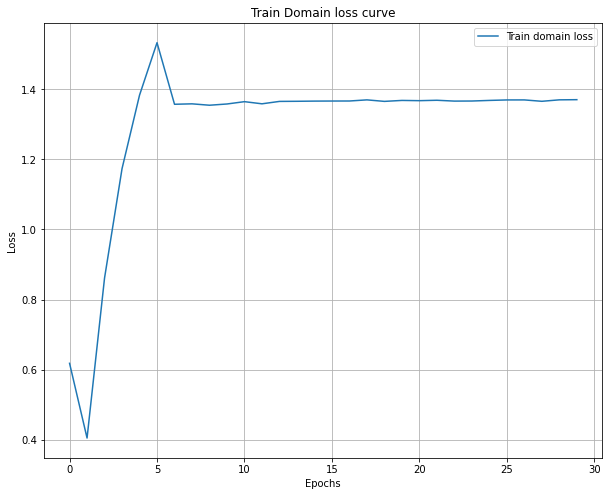

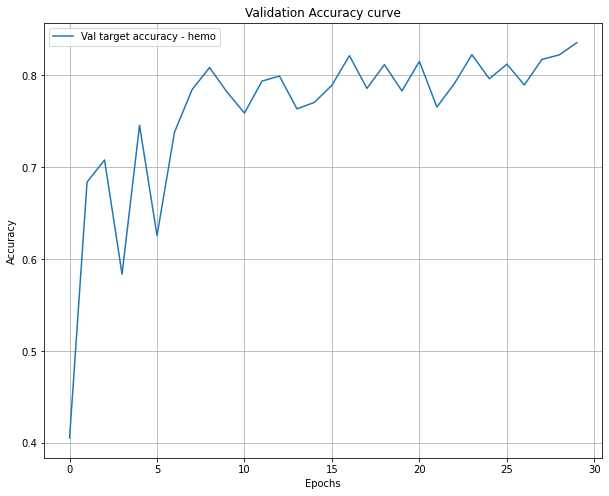

In [8]:
source_train_dataloader = torch.utils.data.DataLoader(source_train_data, batch_size=16, num_workers=1, shuffle=True)                       
source_val_dataloader = torch.utils.data.DataLoader(source_val_data, batch_size=16, num_workers=1)

target_train_dataloader = torch.utils.data.DataLoader(target_train_data, batch_size=16, num_workers=1, shuffle=True)
target_val_dataloader = torch.utils.data.DataLoader(target_val_data, batch_size=16, num_workers=1)

# models
feature_extractor = Feature_extractor().to(device)
class_classifier = Class_classifier(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)
domain_classifier = Domain_classifier().to(device)

solver = Solver(src_size, src_shape, src_hemo, src_inc_ones, src_inc_zeros) 
solver.train(feature_extractor, class_classifier, domain_classifier, source_train_dataloader, source_val_dataloader, \
             target_train_dataloader, target_val_dataloader, num_epochs=30)       #effi

In [9]:
feature_extractor = Feature_extractor().to(device)
class_classifier = Class_classifier(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)
domain_classifier = Domain_classifier().to(device)

feature_extractor.load_state_dict(torch.load('models/DANN_hemo_feature_extractor_model_effi_30.pt'))
class_classifier.load_state_dict(torch.load('models/DANN_hemo_label_classifier_model_effi_30.pt'))
domain_classifier.load_state_dict(torch.load('models/DANN_hemo_domain_classifier_model_effi_30.pt'))

source_train_dataloader = torch.utils.data.DataLoader(source_train_data, batch_size=16, num_workers=1, shuffle=True)                       
source_val_dataloader = torch.utils.data.DataLoader(source_val_data, batch_size=16, num_workers=1)

target_train_dataloader = torch.utils.data.DataLoader(target_train_data, batch_size=16, num_workers=1, shuffle=True)
target_val_dataloader = torch.utils.data.DataLoader(target_val_data, batch_size=16, num_workers=1)

solver = Solver(src_size, src_shape, src_hemo, src_inc_ones, src_inc_zeros) 

Loaded pretrained weights for efficientnet-b7


In [10]:
model_predictions = solver.validate(feature_extractor, class_classifier, domain_classifier, target_val_dataloader)#20 

------------------------------------------------------------------------
Validation hemo_dist: 0.8356, domain : 0.5124 



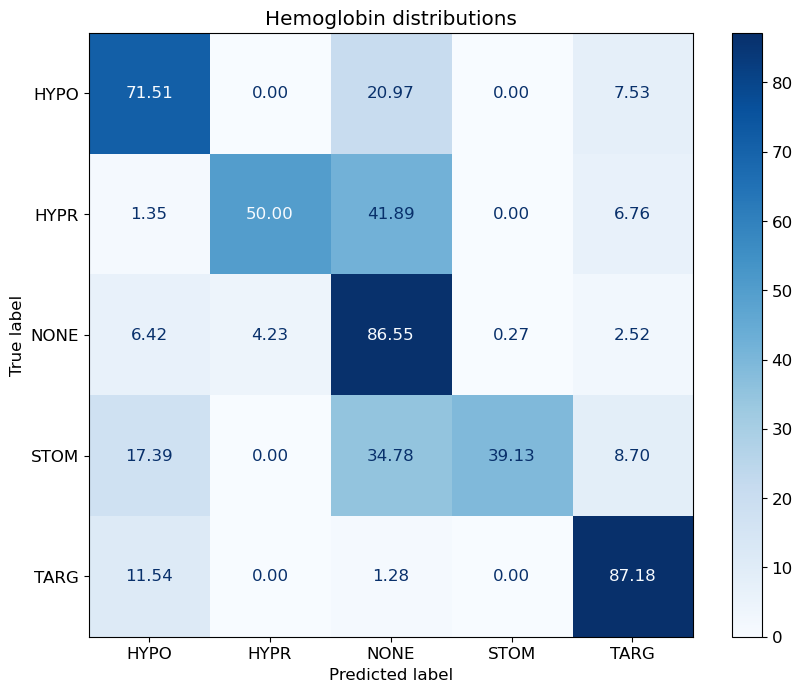

In [11]:
# Visualization of the trained model    - with target data
visualize_grid(target_val_data, attributes, *model_predictions)

In [12]:
model_predictions = solver.validate(feature_extractor, class_classifier, domain_classifier, source_val_dataloader)#20

------------------------------------------------------------------------
Validation hemo_dist: 0.8748, domain : 0.4049 



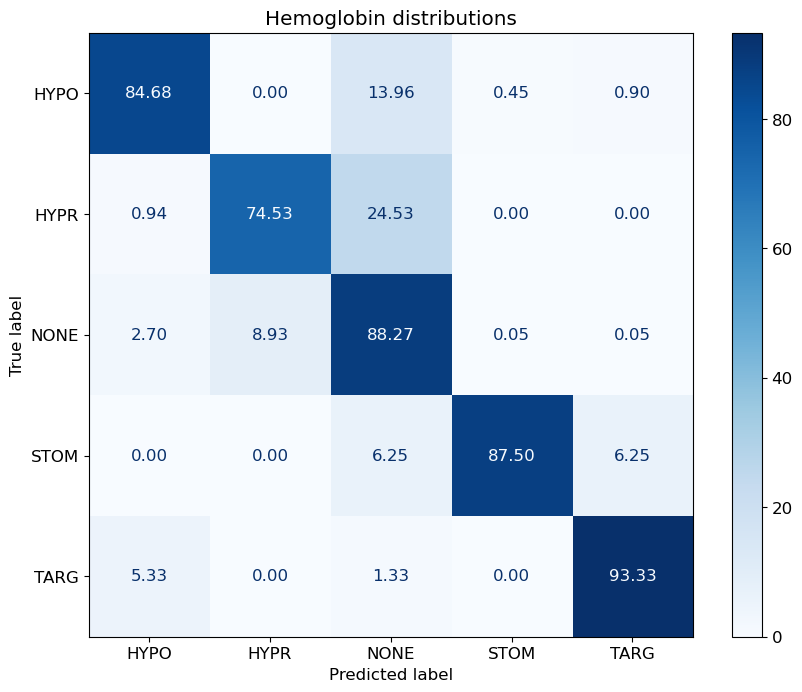

In [13]:
# Visualization of the trained model  - with source data
visualize_grid(source_val_data, attributes, *model_predictions)

### Visualization of deep learning features

In [12]:
from vis_utils import visualizePerformance
d_tsne, tags = visualizePerformance(feature_extractor, class_classifier, domain_classifier, source_val_dataloader, target_val_dataloader)

torch.Size([2379, 5])
torch.Size([2379])
torch.Size([2183, 5])
torch.Size([2183])
(4562, 2)


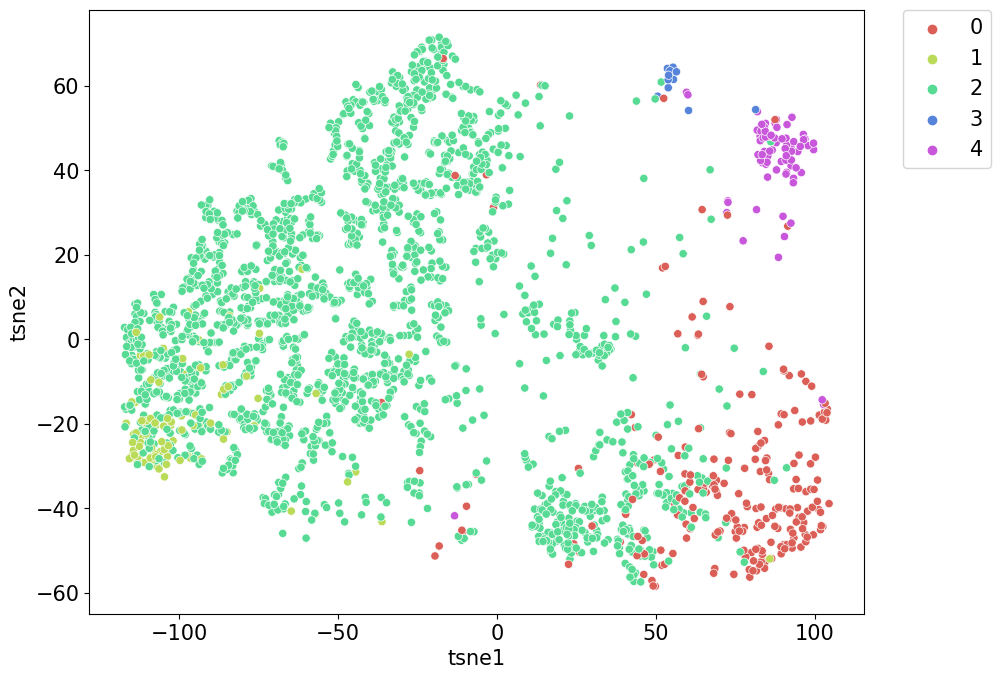

In [13]:
import pandas as pd
df_tsne = pd.DataFrame(data = d_tsne[0:2379], columns = ['tsne1','tsne2'])

sns.scatterplot(x="tsne1", y="tsne2", hue=np.array(tags[0:2379]), data=df_tsne, palette=sns.color_palette("hls", 5))
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0.)

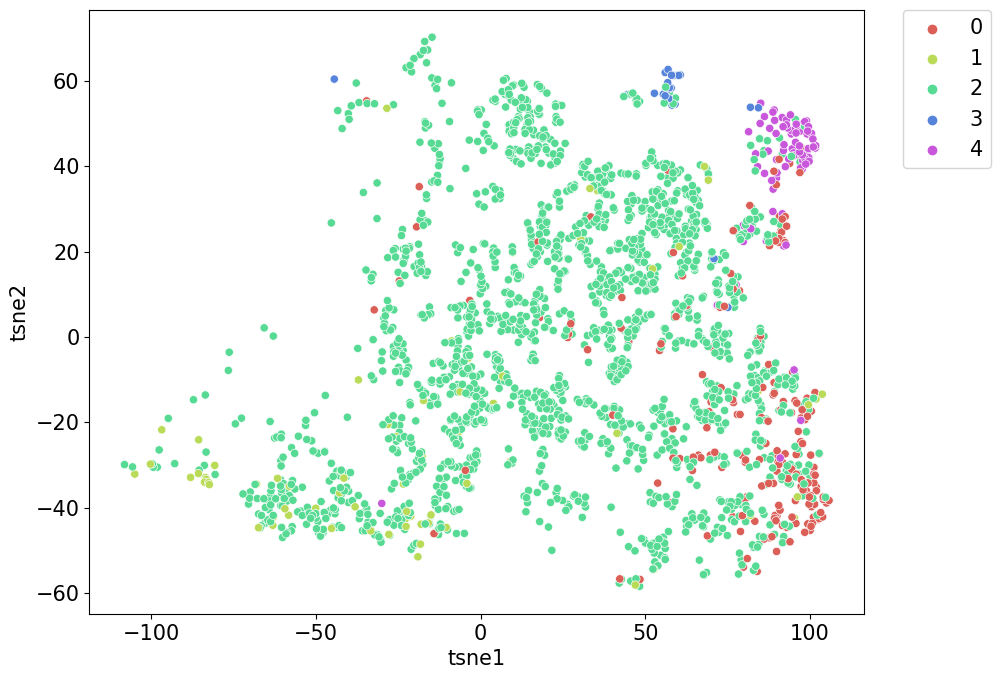

In [14]:
import pandas as pd
df_tsne = pd.DataFrame(data = d_tsne[2379:], columns = ['tsne1','tsne2'])     #np.array(tags[2379:]-11)

sns.scatterplot(x="tsne1", y="tsne2", hue=np.array(tags[2379:]-5), data=df_tsne, palette=sns.color_palette("hls", 5))
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0.)